# Virexo – Lead Conversion Prediction

**Task 02 — AI & Machine Learning | Virexo Innovations**

## Objective

Virexo Innovations receives inbound leads from several channels. Not every lead becomes a
customer, and the sales team has limited hours in the day. The goal of this project is to
build a small classification model that estimates **how likely an incoming lead is to
convert**, so that follow-up effort can be pointed at the leads most likely to pay off.

## Dataset

The dataset is **synthetic (dummy data)**, generated specifically for this task — no public
dataset was used. It was built to imitate a realistic CRM export from a digital services
agency, including the kind of mess a real export contains: missing fields, inconsistent
text casing, duplicate rows, and a few impossible values.

File: `virexo_leads.csv` — 1,435 rows, 11 columns.

| Column | Meaning |
|---|---|
| `lead_id` | Unique lead reference |
| `age_group` | Age bracket of the lead |
| `service_interest` | Service the lead enquired about |
| `lead_source` | Channel the lead arrived through |
| `budget_range` | Budget band indicated during enquiry |
| `previous_interaction` | Whether the lead had contact with Virexo before |
| `response_time_hours` | Hours between enquiry and first sales reply |
| `pages_visited` | Website pages viewed before enquiring |
| `email_opens` | Marketing emails opened |
| `engagement_score` | Composite 0–100 engagement measure |
| `converted` | **Target** — 1 = became a customer, 0 = did not |

## Notebook structure

1. Setup
2. Load and inspect
3. Data quality audit
4. Cleaning and preprocessing
5. Exploratory data analysis
6. Feature selection and encoding
7. Train/test split
8. Model training
9. Evaluation
10. Example prediction
11. Business interpretation
12. Limitations and assumptions


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay)

RANDOM_STATE = 42
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

print("Setup complete.")

Setup complete.


## 2. Load and inspect

First look at the raw file, before any cleaning.

In [2]:
df_raw = pd.read_csv("virexo_leads.csv")

print("Shape:", df_raw.shape)
df_raw.head(10)

Shape: (1435, 11)


,lead_id,age_group,service_interest,lead_source,budget_range,previous_interaction,response_time_hours,pages_visited,email_opens,engagement_score,converted
0,VX-100363,18-24,Web Development,Paid Ads,NaN,Yes,18.3,4,3,72.0,0
1,VX-100823,35-44,Web Development,Paid Ads,Medium,No,39.8,4,3,53.0,1
2,VX-100872,55+,App Development,Social Media,Medium,No,15.3,3,1,42.0,0
3,VX-100405,45-54,SEO,Social Media,Low,No,3.3,2,2,43.0,0
4,VX-100605,45-54,Branding,Paid Ads,Medium,No,6.4,3,2,36.0,1
5,VX-100675,25-34,Digital Marketing,Social Media,Medium,No,35.3,5,1,41.0,0
6,VX-101129,55+,SEO,Email Campaign,Low,No,4.3,2,2,32.0,0
7,VX-100107,25-34,Digital Marketing,Website Form,Low,no,15.1,4,1,28.0,0
8,VX-101390,55+,App Development,Website Form,Medium,Yes,17.4,6,0,47.0,1
9,VX-100245,45-54,Digital Marketing,Email Campaign,Medium,No,-17.7,4,2,44.0,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lead_id               1435 non-null   str    
 1   age_group             1400 non-null   str    
 2   service_interest      1435 non-null   str    
 3   lead_source           1435 non-null   str    
 4   budget_range          1393 non-null   str    
 5   previous_interaction  1435 non-null   str    
 6   response_time_hours   1386 non-null   float64
 7   pages_visited         1435 non-null   int64  
 8   email_opens           1435 non-null   int64  
 9   engagement_score      1371 non-null   float64
 10  converted             1435 non-null   int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 123.4 KB


In [4]:
df_raw.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
response_time_hours,1386.0,14.636075,11.556277,-18.2,6.5,11.7,20.2,75.1
pages_visited,1435.0,4.468293,2.212761,1.0,3.0,4.0,6.0,16.0
email_opens,1435.0,2.397909,1.711352,0.0,1.0,2.0,3.0,9.0
engagement_score,1371.0,54.686360,25.121473,4.0,41.0,52.0,64.0,368.0
converted,1435.0,0.403484,0.490767,0.0,0.0,0.0,1.0,1.0


## 3. Data quality audit

Before modelling, it's worth knowing exactly what is wrong with the data. Four problems
show up in this export.

In [5]:
# 3.1 Missing values
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing": missing, "percent": missing_pct}).query("missing > 0")

,missing,percent
age_group,35,2.44
budget_range,42,2.93
response_time_hours,49,3.41
engagement_score,64,4.46


In [6]:
# 3.2 Duplicate rows
print("Fully duplicated rows:", df_raw.duplicated().sum())
print("Duplicated lead_id values:", df_raw.lead_id.duplicated().sum())

Fully duplicated rows: 35
Duplicated lead_id values: 35


In [7]:
# 3.3 Inconsistent text values in categorical columns
for col in ["previous_interaction", "service_interest", "budget_range", "lead_source", "age_group"]:
    print(f"{col}: {sorted(df_raw[col].dropna().unique().tolist())}")
    print()

previous_interaction: ['NO', 'No', 'YES', 'Yes', 'no', 'yes']

service_interest: [' App Development ', ' Branding ', ' Digital Marketing ', ' SEO ', ' Web Development ', 'App Development', 'Branding', 'Digital Marketing', 'SEO', 'Web Development']

budget_range: ['High', 'Low', 'Medium', 'high', 'low', 'medium']

lead_source: ['Email Campaign', 'Paid Ads', 'Referral', 'Social Media', 'Website Form']

age_group: ['18-24', '25-34', '35-44', '45-54', '55+']



In [8]:
# 3.4 Impossible / out-of-range numeric values
print("Negative response times:", (df_raw.response_time_hours < 0).sum())
print("Engagement score above 100:", (df_raw.engagement_score > 100).sum())
print("Response time range:", df_raw.response_time_hours.min(), "to", df_raw.response_time_hours.max())
print("Engagement score range:", df_raw.engagement_score.min(), "to", df_raw.engagement_score.max())

Negative response times: 13
Engagement score above 100: 8
Response time range: -18.2 to 75.1
Engagement score range: 4.0 to 368.0


**Summary of issues found**

| Issue | Detail | Fix |
|---|---|---|
| Duplicate rows | 35 exact duplicates | Drop them |
| Inconsistent casing | `Yes` / `yes` / `YES`, `Low` / `low` | Standardise casing |
| Stray whitespace | `" SEO "` etc. | Strip whitespace |
| Missing values | 4 columns, 2–4.5% each | Impute (median / mode) |
| Impossible values | Negative response times, engagement > 100 | Treat as missing, then impute |


## 4. Cleaning and preprocessing

Each step below is applied in order, with a count printed so the effect is visible.

In [9]:
df = df_raw.copy()

# --- Step 1: drop exact duplicate rows ---
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Step 1 — dropped {before - len(df)} duplicate rows. Rows now: {len(df)}")

Step 1 — dropped 35 duplicate rows. Rows now: 1400


In [10]:
# --- Step 2: standardise categorical text (strip whitespace, fix casing) ---
text_cols = ["age_group", "service_interest", "lead_source", "budget_range", "previous_interaction"]

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# Title-case the ones where casing varies; age_group is left as-is (it's numeric ranges)
for col in ["service_interest", "lead_source", "budget_range", "previous_interaction"]:
    df[col] = df[col].str.title()

print("Step 2 — categorical values after standardisation:")
for col in text_cols:
    print(f"  {col}: {sorted(df[col].dropna().unique().tolist())}")

Step 2 — categorical values after standardisation:
  age_group: ['18-24', '25-34', '35-44', '45-54', '55+']
  service_interest: ['App Development', 'Branding', 'Digital Marketing', 'Seo', 'Web Development']
  lead_source: ['Email Campaign', 'Paid Ads', 'Referral', 'Social Media', 'Website Form']
  budget_range: ['High', 'Low', 'Medium']
  previous_interaction: ['No', 'Yes']


In [11]:
# --- Step 3: treat impossible numeric values as missing ---
n_bad_rt = (df.response_time_hours < 0).sum()
n_bad_eng = (df.engagement_score > 100).sum()

df.loc[df.response_time_hours < 0, "response_time_hours"] = np.nan
df.loc[df.engagement_score > 100, "engagement_score"] = np.nan

print(f"Step 3 — nulled {n_bad_rt} negative response times and {n_bad_eng} out-of-range engagement scores.")

Step 3 — nulled 12 negative response times and 8 out-of-range engagement scores.


In [12]:
# --- Step 4: impute missing values ---
# Numeric -> median (robust to the skew in response_time_hours)
# Categorical -> mode
num_impute = ["response_time_hours", "engagement_score"]
cat_impute = ["age_group", "budget_range"]

for col in num_impute:
    fill = df[col].median()
    n = df[col].isna().sum()
    df[col] = df[col].fillna(fill)
    print(f"  {col}: filled {n} missing with median = {fill}")

for col in cat_impute:
    fill = df[col].mode()[0]
    n = df[col].isna().sum()
    df[col] = df[col].fillna(fill)
    print(f"  {col}: filled {n} missing with mode = '{fill}'")

print("\nStep 4 — remaining missing values:", df.isna().sum().sum())

  response_time_hours: filled 61 missing with median = 11.8
  engagement_score: filled 69 missing with median = 52.0
  age_group: filled 35 missing with mode = '25-34'
  budget_range: filled 42 missing with mode = 'Low'

Step 4 — remaining missing values: 0


In [13]:
# --- Step 5: final type fixes and sanity check ---
df["previous_interaction"] = df["previous_interaction"].map({"Yes": 1, "No": 0}).astype(int)
df["engagement_score"] = df["engagement_score"].astype(float)
df["converted"] = df["converted"].astype(int)

for col in ["age_group", "service_interest", "lead_source", "budget_range"]:
    df[col] = df[col].astype(str)

print("Clean dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())
df.head()

Clean dataset shape: (1400, 11)
Missing values: 0
Duplicates: 0


,lead_id,age_group,service_interest,lead_source,budget_range,previous_interaction,response_time_hours,pages_visited,email_opens,engagement_score,converted
0,VX-100363,18-24,Web Development,Paid Ads,Low,1,18.3,4,3,72.0,0
1,VX-100823,35-44,Web Development,Paid Ads,Medium,0,39.8,4,3,53.0,1
2,VX-100872,55+,App Development,Social Media,Medium,0,15.3,3,1,42.0,0
3,VX-100405,45-54,Seo,Social Media,Low,0,3.3,2,2,43.0,0
4,VX-100605,45-54,Branding,Paid Ads,Medium,0,6.4,3,2,36.0,1


In [14]:
# Target balance — important to know before choosing metrics
counts = df.converted.value_counts().sort_index()
print(counts)
print()
print("Conversion rate: {:.1%}".format(df.converted.mean()))

converted
0    834
1    566
Name: count, dtype: int64

Conversion rate: 40.4%


The classes are reasonably balanced (roughly 60/40), so accuracy is not
meaningless here — but precision, recall and F1 are still reported because the
business cost of a missed conversion is not the same as a wasted follow-up call.

## 5. Exploratory data analysis

Four visualisations, each chosen to answer a specific business question.

### 5.1 Which channels and services actually convert?

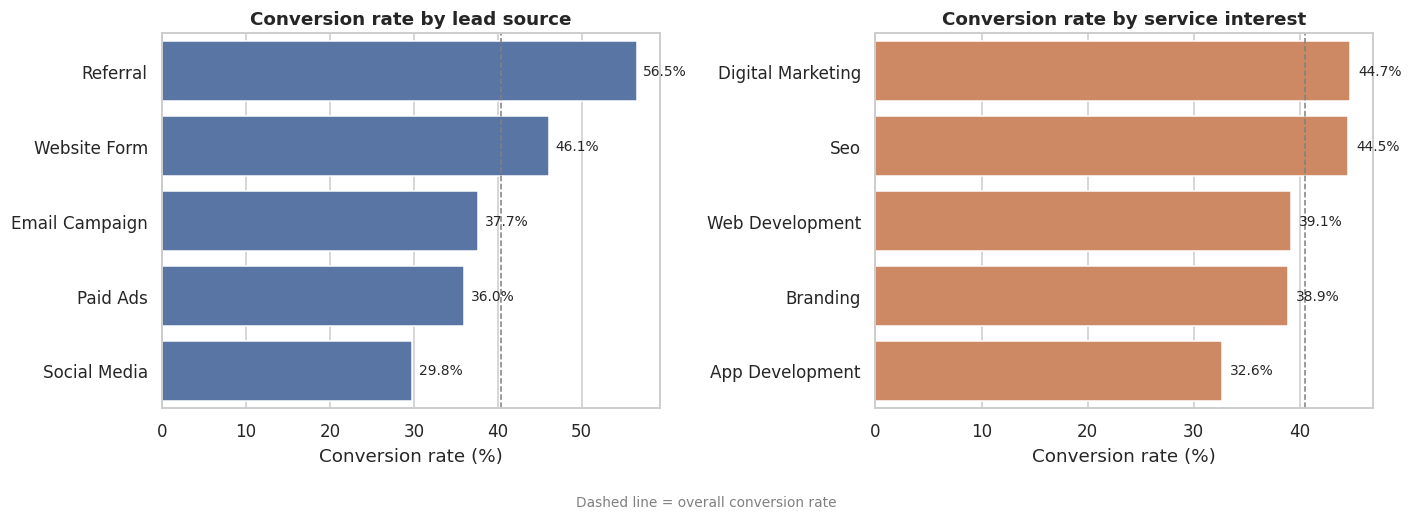

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

src = (df.groupby("lead_source")["converted"].mean().sort_values(ascending=False) * 100)
sns.barplot(x=src.values, y=src.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Conversion rate by lead source", fontsize=12, weight="bold")
axes[0].set_xlabel("Conversion rate (%)")
axes[0].set_ylabel("")
for i, v in enumerate(src.values):
    axes[0].text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=9)

svc = (df.groupby("service_interest")["converted"].mean().sort_values(ascending=False) * 100)
sns.barplot(x=svc.values, y=svc.index, ax=axes[1], color="#DD8452")
axes[1].set_title("Conversion rate by service interest", fontsize=12, weight="bold")
axes[1].set_xlabel("Conversion rate (%)")
axes[1].set_ylabel("")
for i, v in enumerate(svc.values):
    axes[1].text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=9)

axes[0].axvline(df.converted.mean() * 100, ls="--", color="grey", lw=1)
axes[1].axvline(df.converted.mean() * 100, ls="--", color="grey", lw=1)
plt.suptitle("Dashed line = overall conversion rate", y=-0.02, fontsize=9, color="grey")
plt.tight_layout()
plt.show()

**Reading this:** Referrals convert far above the company average, while social media
sits well below it. On the service side, digital marketing and web development enquiries
convert better than branding enquiries. Same marketing spend, very different returns.

### 5.2 Does engagement separate converters from non-converters?

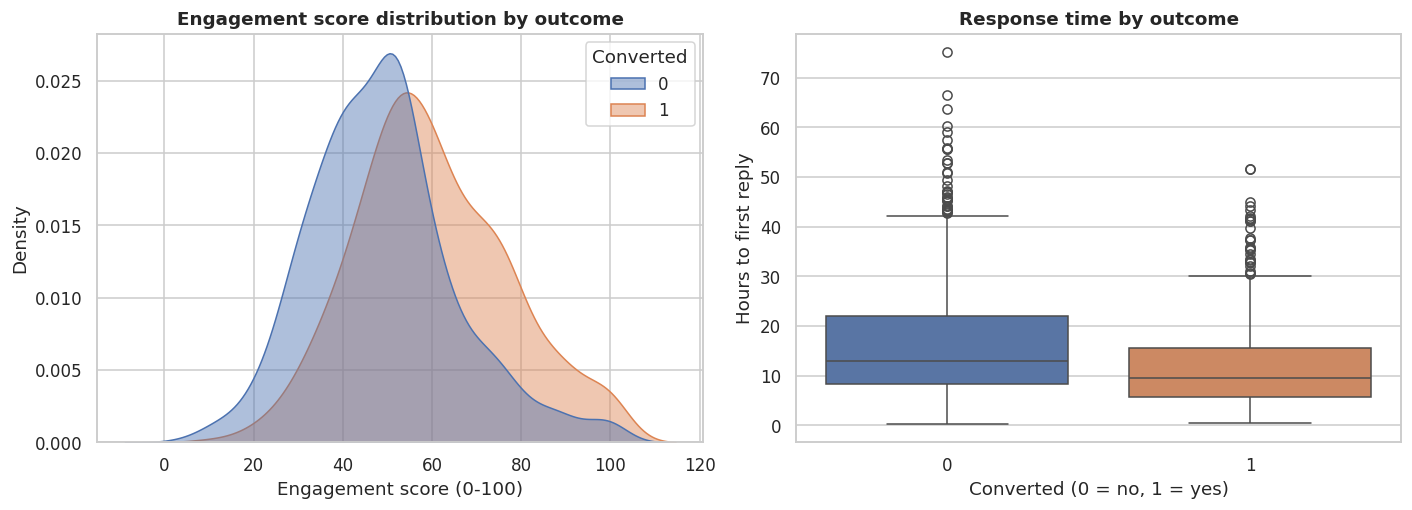

           engagement_score  response_time_hours  pages_visited  email_opens
converted                                                                   
0                     48.76                16.49           3.99         2.14
1                     59.89                12.03           5.14         2.78


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.kdeplot(data=df, x="engagement_score", hue="converted", fill=True,
            alpha=0.45, common_norm=False, ax=axes[0])
axes[0].set_title("Engagement score distribution by outcome", fontsize=12, weight="bold")
axes[0].set_xlabel("Engagement score (0-100)")
axes[0].legend_.set_title("Converted")

sns.boxplot(data=df, x="converted", y="response_time_hours", ax=axes[1],
            hue="converted", legend=False)
axes[1].set_title("Response time by outcome", fontsize=12, weight="bold")
axes[1].set_xlabel("Converted (0 = no, 1 = yes)")
axes[1].set_ylabel("Hours to first reply")

plt.tight_layout()
plt.show()

print(df.groupby("converted")[["engagement_score", "response_time_hours",
                               "pages_visited", "email_opens"]].mean().round(2))

**Reading this:** Converters sit noticeably higher on the engagement score, and the
leads that were replied to quickly converted more often. Response time is one of the few
variables on this list the business directly controls.

### 5.3 Budget, prior contact, and how the numeric features relate

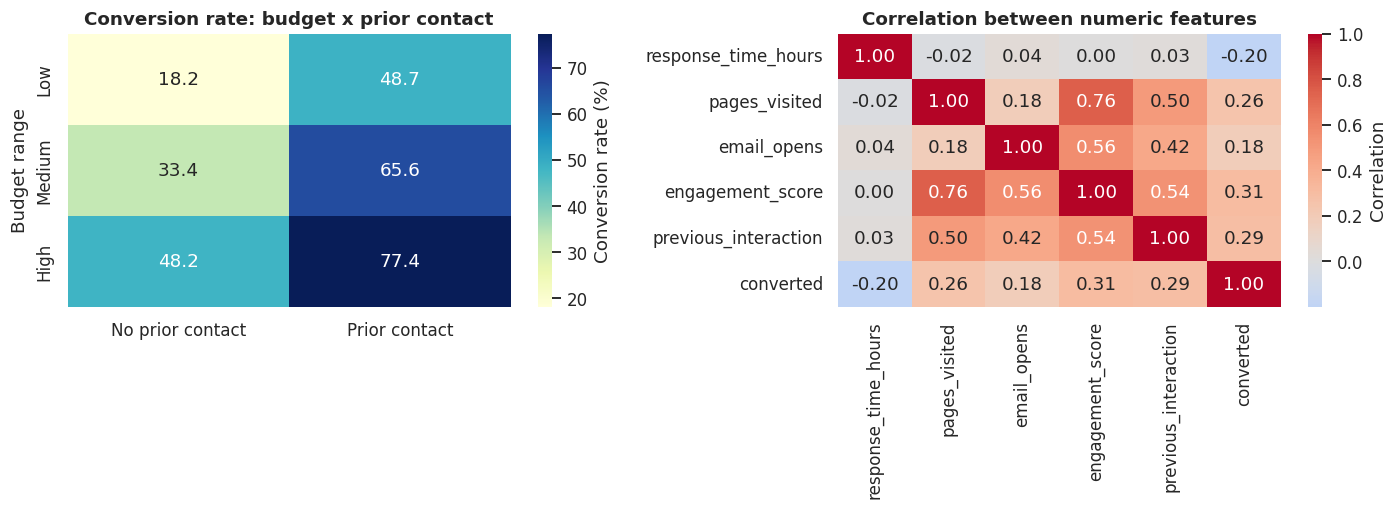

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

pivot = (df.pivot_table(index="budget_range", columns="previous_interaction",
                        values="converted", aggfunc="mean") * 100)
pivot = pivot.reindex(["Low", "Medium", "High"])
pivot.columns = ["No prior contact", "Prior contact"]
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={"label": "Conversion rate (%)"})
axes[0].set_title("Conversion rate: budget x prior contact", fontsize=12, weight="bold")
axes[0].set_ylabel("Budget range")
axes[0].set_xlabel("")

num_cols = ["response_time_hours", "pages_visited", "email_opens",
            "engagement_score", "previous_interaction", "converted"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1],
            cbar_kws={"label": "Correlation"})
axes[1].set_title("Correlation between numeric features", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

**Reading this:** High-budget leads who have dealt with Virexo before are the single
strongest segment. The correlation map confirms `engagement_score` is built from
`pages_visited` and `email_opens` — they overlap heavily, which matters when interpreting
feature importance later.

### 5.4 Age group

In [18]:
age_tab = (df.groupby("age_group")
             .agg(leads=("converted", "size"), conversion_rate=("converted", "mean"))
             .assign(conversion_rate=lambda d: (d.conversion_rate * 100).round(1))
             .sort_index())
age_tab

,leads,conversion_rate
age_group,,
18-24,202,33.2
25-34,498,41.8
35-44,351,45.3
45-54,237,41.4
55+,112,30.4


## 6. Feature selection and target variable

**Target:** `converted` — 1 if the lead became a paying customer, 0 otherwise.

**Features used:**

- Categorical: `age_group`, `service_interest`, `lead_source`, `budget_range` → one-hot encoded
- Numeric: `response_time_hours`, `pages_visited`, `email_opens`, `engagement_score` → scaled
- Binary: `previous_interaction` (already 0/1)

**Dropped:** `lead_id` — a unique identifier carries no predictive information and would
only let the model memorise rows.

In [19]:
TARGET = "converted"
DROP = ["lead_id"]

categorical = ["age_group", "service_interest", "lead_source", "budget_range"]
numeric = ["response_time_hours", "pages_visited", "email_opens", "engagement_score"]
passthrough = ["previous_interaction"]

X = df.drop(columns=DROP + [TARGET])
y = df[TARGET]

print("Feature matrix:", X.shape)
print("Categorical:", categorical)
print("Numeric:", numeric)
print("Binary passthrough:", passthrough)

Feature matrix: (1400, 9)
Categorical: ['age_group', 'service_interest', 'lead_source', 'budget_range']
Numeric: ['response_time_hours', 'pages_visited', 'email_opens', 'engagement_score']
Binary passthrough: ['previous_interaction']


## 7. Train/test split

An 80/20 split, **stratified** on the target so the train and test sets carry the same
conversion rate. Without stratification the test set could end up with a different class
balance and the metrics would be misleading.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape[0]} rows | conversion rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]} rows | conversion rate {y_test.mean():.1%}")

Train: 1120 rows | conversion rate 40.4%
Test:  280 rows | conversion rate 40.4%


## 8. Model training

Two classifiers are trained so their results can be compared:

1. **Logistic Regression** — a simple, transparent baseline. Its coefficients can be read
   directly as "this factor pushes conversion up or down", which matters when the output
   has to be explained to a sales team.
2. **Random Forest** — a tree ensemble that can pick up non-linear effects and interactions
   the logistic model would miss.

All preprocessing is wrapped inside a scikit-learn `Pipeline`. This is important: the
scaler and encoder are fitted on the training fold only, so no information leaks from the
test set into training.

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numeric),
    ],
    remainder="passthrough",   # previous_interaction passes through unchanged
)

logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1)),
])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


### 8.1 Cross-validation on the training set

A single split can be lucky. Five-fold cross-validation on the training data gives a more
honest sense of how stable each model is before it ever touches the test set.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [("Logistic Regression", logreg), ("Random Forest", rf)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    print(f"{name:22s} CV F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression    CV F1: 0.626 (+/- 0.041)


Random Forest          CV F1: 0.598 (+/- 0.030)


## 9. Evaluation

Metrics reported on the held-out test set, which neither model has seen.

- **Accuracy** — share of all leads classified correctly.
- **Precision** — of the leads flagged as "will convert", how many actually did. Low
  precision means the sales team wastes time on leads that were never going to buy.
- **Recall** — of the leads that actually converted, how many the model caught. Low recall
  means real revenue is being ignored.
- **F1-score** — the balance between the two.
- **ROC-AUC** — how well the model ranks leads from least to most likely, across all
  thresholds. This is the metric that matters most for a prioritisation use case.

In [23]:
def evaluate(name, model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall": recall_score(y_te, pred),
        "F1": f1_score(y_te, pred),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", logreg, X_test, y_test),
    evaluate("Random Forest", rf, X_test, y_test),
]).set_index("Model").round(3)

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.700,0.656,0.540,0.592,0.772
Random Forest,0.693,0.652,0.513,0.574,0.762


In [24]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, logreg.predict(X_test),
                            target_names=["Not converted", "Converted"]))
print("\nRANDOM FOREST")
print(classification_report(y_test, rf.predict(X_test),
                            target_names=["Not converted", "Converted"]))

LOGISTIC REGRESSION
               precision    recall  f1-score   support

Not converted       0.72      0.81      0.76       167
    Converted       0.66      0.54      0.59       113

     accuracy                           0.70       280
    macro avg       0.69      0.67      0.68       280
 weighted avg       0.70      0.70      0.69       280


RANDOM FOREST
               precision    recall  f1-score   support

Not converted       0.71      0.81      0.76       167
    Converted       0.65      0.51      0.57       113

     accuracy                           0.69       280
    macro avg       0.68      0.66      0.67       280
 weighted avg       0.69      0.69      0.68       280



### 9.1 Confusion matrices

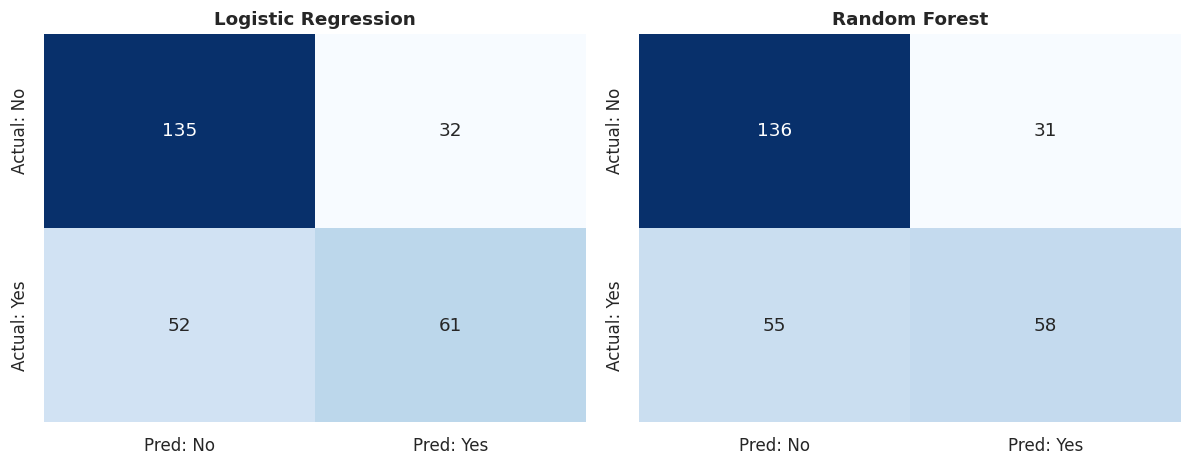

Logistic Regression, in plain terms:
  61 leads correctly flagged as likely converters (true positives)
  135 leads correctly set aside as unlikely (true negatives)
  32 leads chased that did not convert (false positives - wasted effort)
  52 real converters the model missed (false negatives - lost revenue)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for ax, (name, model) in zip(axes, [("Logistic Regression", logreg), ("Random Forest", rf)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: No", "Pred: Yes"],
                yticklabels=["Actual: No", "Actual: Yes"])
    ax.set_title(name, fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, logreg.predict(X_test))
tn, fp, fn, tp = cm.ravel()
print("Logistic Regression, in plain terms:")
print(f"  {tp} leads correctly flagged as likely converters (true positives)")
print(f"  {tn} leads correctly set aside as unlikely (true negatives)")
print(f"  {fp} leads chased that did not convert (false positives - wasted effort)")
print(f"  {fn} real converters the model missed (false negatives - lost revenue)")

### 9.2 ROC curves

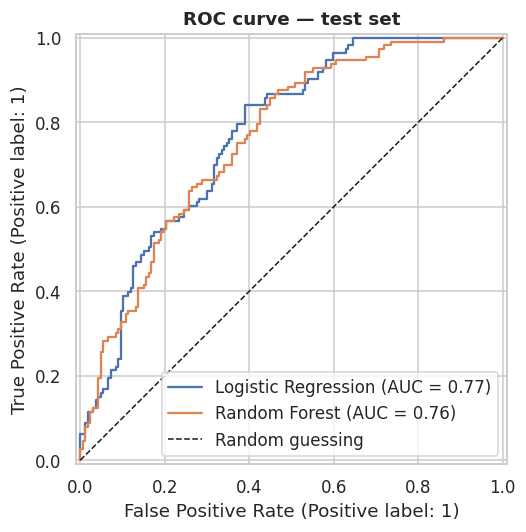

In [26]:
fig, ax = plt.subplots(figsize=(6.2, 5))
RocCurveDisplay.from_estimator(logreg, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guessing")
ax.set_title("ROC curve — test set", fontsize=12, weight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 9.3 The recall problem, and the threshold that causes it

The recall figure above is the weakest number in this project and it should not be glossed
over: at the default 0.5 threshold the model **misses close to half of the leads that
actually converted**. For a sales team, that is real revenue sitting in the "ignore" pile.

This is not really a flaw in the model — it is a consequence of an arbitrary default. A
lead scoring 0.45 is being labelled "will not convert" even though the model thinks it is
nearly a coin-flip. Lowering the threshold catches more converters at the cost of chasing
more people who were never going to buy.

In [27]:
proba = logreg.predict_proba(X_test)[:, 1]

rows = []
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    pred_t = (proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Leads flagged": int(pred_t.sum()),
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t),
        "F1": f1_score(y_test, pred_t),
    })

thresh_df = pd.DataFrame(rows).set_index("Threshold").round(3)
thresh_df

,Leads flagged,Precision,Recall,F1
Threshold,,,,
0.25,191,0.529,0.894,0.664
0.30,158,0.589,0.823,0.686
0.35,143,0.594,0.752,0.664
0.40,132,0.598,0.699,0.645
0.45,108,0.620,0.593,0.606
0.50,93,0.656,0.540,0.592
0.55,80,0.688,0.487,0.570
0.60,64,0.703,0.398,0.508
0.65,52,0.692,0.319,0.436


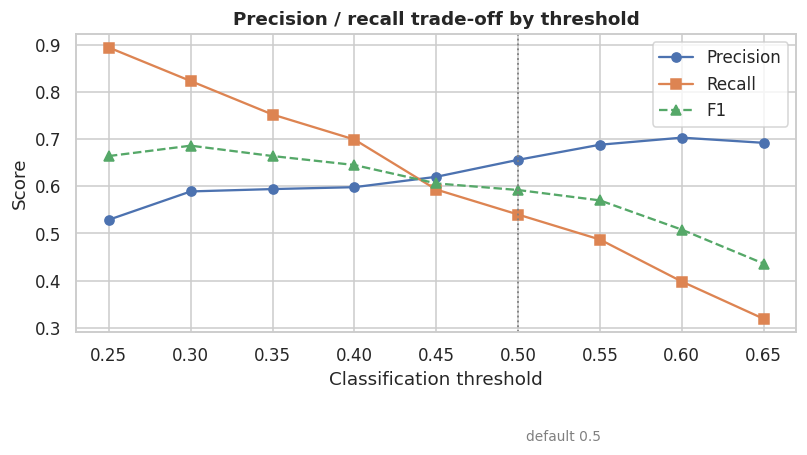

In [28]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(thresh_df.index, thresh_df.Precision, marker="o", label="Precision")
ax.plot(thresh_df.index, thresh_df.Recall, marker="s", label="Recall")
ax.plot(thresh_df.index, thresh_df.F1, marker="^", label="F1", ls="--")
ax.axvline(0.5, color="grey", ls=":", lw=1.2)
ax.text(0.505, 0.06, "default 0.5", fontsize=9, color="grey")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / recall trade-off by threshold", fontsize=12, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**What this table is worth in practice.** Moving the threshold from 0.50 down to 0.30
lifts recall from about 0.54 to about 0.82 — the model goes from catching half the
converters to catching four in five. Precision drops from roughly 0.66 to 0.59, and the
number of leads flagged for follow-up rises from around 93 to around 158.

So the question for Virexo is not technical, it is operational: *can the sales team handle
roughly 65 more calls, knowing about 6 in 10 will be productive rather than 6.6 in 10?* If
the team has capacity, that is an easy yes and a lot of recovered revenue. If they are
already at their limit, the higher threshold is the right call. **This is a business
decision that the model cannot make for itself** — which is exactly why the probability,
not the label, is the useful output.

### 9.4 What is driving the predictions?

In [29]:
# Logistic regression coefficients, translated into odds ratios
feat_names = logreg.named_steps["prep"].get_feature_names_out()
coefs = logreg.named_steps["clf"].coef_[0]

coef_df = (pd.DataFrame({"feature": feat_names, "coefficient": coefs})
             .assign(odds_ratio=lambda d: np.exp(d.coefficient))
             .sort_values("coefficient", ascending=False)
             .reset_index(drop=True))

coef_df["feature"] = coef_df.feature.str.replace("cat__|num__|remainder__", "", regex=True)
coef_df.round(3)

,feature,coefficient,odds_ratio
0,previous_interaction,0.961,2.615
1,service_interest_Digital Marketing,0.567,1.763
2,lead_source_Referral,0.526,1.692
3,engagement_score,0.518,1.679
4,age_group_35-44,0.397,1.488
5,age_group_25-34,0.376,1.456
6,age_group_45-54,0.371,1.449
7,service_interest_Seo,0.245,1.278
8,lead_source_Website Form,0.241,1.273
9,service_interest_Branding,0.235,1.265


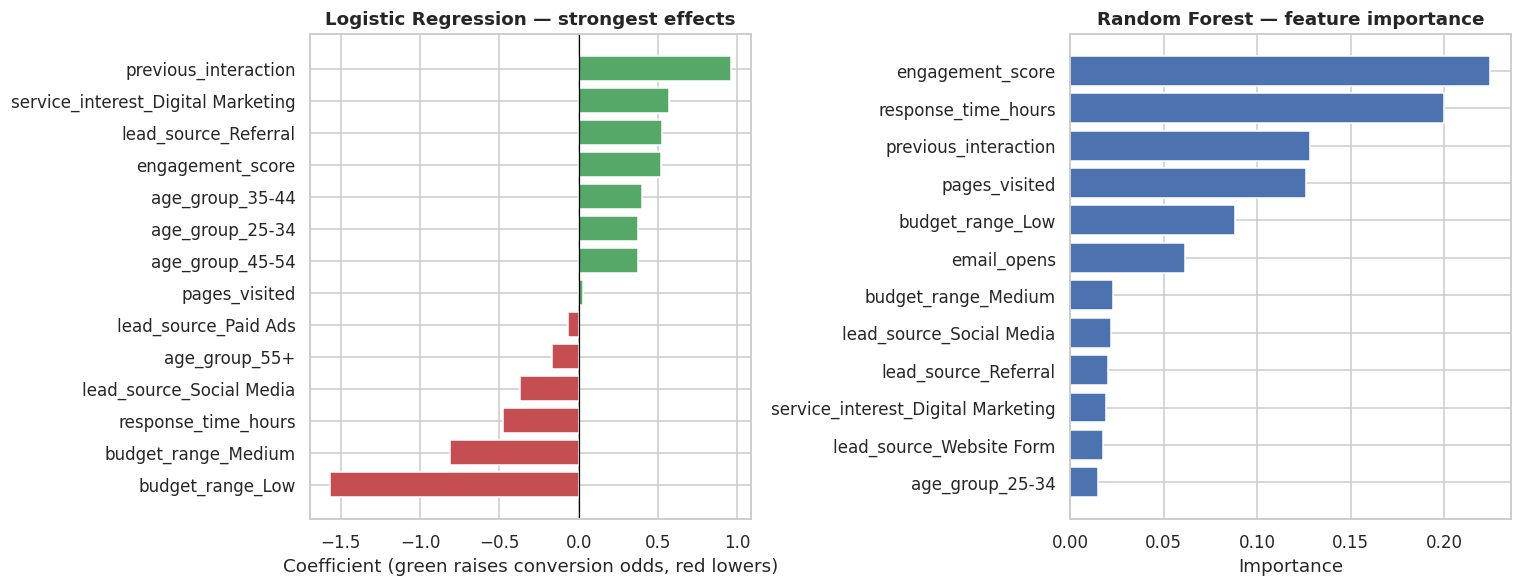

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

top = pd.concat([coef_df.head(7), coef_df.tail(7)])
colors = ["#55A868" if v > 0 else "#C44E52" for v in top.coefficient]
axes[0].barh(top.feature, top.coefficient, color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Logistic Regression — strongest effects", fontsize=12, weight="bold")
axes[0].set_xlabel("Coefficient (green raises conversion odds, red lowers)")
axes[0].invert_yaxis()

rf_imp = (pd.DataFrame({
    "feature": pd.Series(feat_names).str.replace("cat__|num__|remainder__", "", regex=True),
    "importance": rf.named_steps["clf"].feature_importances_})
    .sort_values("importance", ascending=False).head(12))
axes[1].barh(rf_imp.feature, rf_imp.importance, color="#4C72B0")
axes[1].set_title("Random Forest — feature importance", fontsize=12, weight="bold")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Both models agree on the story: **engagement score, prior interaction, budget and
response time do the heavy lifting**, with referral traffic as a strong positive channel
signal. That agreement between two very different algorithms is reassuring — it suggests
the pattern is in the data, not an artefact of one model's assumptions.

It is also worth noting that the **Random Forest did not beat the Logistic Regression** —
it scored slightly lower on every metric, both in cross-validation and on the test set.
That is a useful result rather than a disappointing one. It suggests the relationships here
are largely additive, with little in the way of complex interactions for a tree ensemble to
exploit. Given the simpler model matches it and is far easier to explain to a sales team,
**Logistic Regression is the better choice for this use case** — the extra complexity of the
forest buys nothing.

## 10. Example predictions

The real output of this model is not a yes/no label — it is a **probability**, which can be
used to rank and prioritise. Below are three leads a sales team might realistically receive
on the same morning.

In [31]:
new_leads = pd.DataFrame([
    {   # Lead A — warm, high intent
        "age_group": "35-44", "service_interest": "Digital Marketing",
        "lead_source": "Referral", "budget_range": "High",
        "previous_interaction": 1, "response_time_hours": 2.0,
        "pages_visited": 9, "email_opens": 6, "engagement_score": 88.0,
    },
    {   # Lead B — middle of the road
        "age_group": "35-44", "service_interest": "Web Development",
        "lead_source": "Website Form", "budget_range": "Medium",
        "previous_interaction": 0, "response_time_hours": 8.0,
        "pages_visited": 5, "email_opens": 3, "engagement_score": 60.0,
    },
    {   # Lead C — cold, slow follow-up
        "age_group": "18-24", "service_interest": "Branding",
        "lead_source": "Social Media", "budget_range": "Low",
        "previous_interaction": 0, "response_time_hours": 46.0,
        "pages_visited": 1, "email_opens": 0, "engagement_score": 17.0,
    },
], index=["Lead A", "Lead B", "Lead C"])

new_leads

,age_group,service_interest,lead_source,budget_range,previous_interaction,response_time_hours,pages_visited,email_opens,engagement_score
Lead A,35-44,Digital Marketing,Referral,High,1,2.0,9,6,88.0
Lead B,35-44,Web Development,Website Form,Medium,0,8.0,5,3,60.0
Lead C,18-24,Branding,Social Media,Low,0,46.0,1,0,17.0


In [32]:
proba_lr = logreg.predict_proba(new_leads)[:, 1]
proba_rf = rf.predict_proba(new_leads)[:, 1]

out = pd.DataFrame({
    "LogReg probability": proba_lr.round(3),
    "RandomForest probability": proba_rf.round(3),
    "Predicted class (LogReg)": logreg.predict(new_leads),
}, index=new_leads.index)
out["Priority"] = pd.cut(proba_lr, bins=[0, 0.35, 0.65, 1.0],
                         labels=["Low", "Medium", "High"])
out

,LogReg probability,RandomForest probability,Predicted class (LogReg),Priority
Lead A,0.977,0.798,1,High
Lead B,0.495,0.573,0,Medium
Lead C,0.010,0.115,0,Low


### What these predictions mean for the business

**Lead A — about a 98% chance of converting.** A high-budget referral who has dealt with
Virexo before, browsed heavily, and was called back within two hours. This lead should go to
a senior salesperson today. The model is not telling the team anything they could not work
out themselves here — but it is confirming the instinct with a number, and it will apply
that same judgement consistently across hundreds of leads, at 3pm on a busy Friday, without
getting tired.

Note that the Random Forest is less confident about Lead A (around 0.80). When two models
disagree in strength like this, the honest reading is that the true probability is high but
not as pinned-down as the 98% suggests.

**Lead B — almost exactly a coin-flip, around 0.50.** This is where the model earns its
keep. Nothing about Lead B stands out in either direction, so a human eye skims past it in a
long list. The model says it is genuinely worth working, and it also hints at *how*:
response time and engagement are the two levers in the feature list that Virexo actually
controls. Reply faster, get them onto more pages, and this lead's probability moves up.

**Lead B is also the clearest argument for the threshold discussion in section 9.3.** At the
default 0.5 cutoff this lead sits right on the boundary — a rounding error decides whether
anyone calls them. At a 0.35 threshold it is comfortably in the "follow up" pile.

**Lead C — around 1%.** Low budget, social media, no prior contact, replied to two days
late. Not worthless, but it does not deserve a phone call ahead of A or B. Drop it into an
automated nurture sequence and revisit if engagement picks up.

**The practical shift:** the team stops working the list in the order it arrived and starts
working it in order of probability.

## 11. Business interpretation

**How good is the model, in plain language?**

On leads it had never seen, the model gets the outcome right about **7 times out of 10**
(accuracy ≈ 0.70), against a baseline of roughly 60% if you simply guessed "no conversion"
every time. So it is adding real information, but it is not dramatic.

The more meaningful number for this use case is **ROC-AUC of about 0.77**: hand the model
one converter and one non-converter, and it puts them in the correct order about 77% of the
time. For a tool whose job is to *rank* a list rather than to make final calls, that is
genuinely useful — clearly better than working leads in the order they arrived, and clearly
not a crystal ball.

**The honest weak spot** is recall: at the default threshold the model catches only about
54% of actual converters. Section 9.3 shows this is fixable by lowering the threshold, but
it is the number to keep in view. Anyone presenting this model should lead with the
ranking value, not the accuracy figure.

**Where the value actually comes from**

1. **Ranking, not labelling.** The useful output is the probability column. Sorting the
   day's leads by it means the highest-value conversations happen first, while the lead is
   still warm.
2. **Response time is a lever, not just a statistic.** It's one of the strongest negative
   predictors and it is entirely within Virexo's control. Cutting first-reply time is a
   process change, not a budget request.
3. **Channel spend has evidence behind it now.** Referrals convert far above average and
   social media well below it. That is an argument for a referral incentive scheme and a
   harder look at social ad spend.
4. **Prior interaction matters a lot.** Re-engaging past enquiries is cheaper than buying
   new leads and converts better.

**A caution on how the metrics are used**

Precision and recall trade off against each other, and the right balance depends on cost.
If the sales team has spare capacity, favour recall — chase more leads, accept some wasted
calls, catch more revenue. If the team is stretched, favour precision — chase fewer, better
leads. Section 9.3 puts numbers on that trade: dropping the threshold from 0.50 to 0.30
takes recall from roughly 0.54 to 0.82 while precision slips from about 0.66 to 0.59.

The threshold is currently 0.5 only because that is scikit-learn's default. **It should be
set by whoever knows the cost of a wasted call versus a missed sale** — that is a business
decision, not a technical one.

## 12. Limitations and assumptions

**This model is not production-ready. It is a proof of concept built on synthetic data.**

**Data limitations**

- The dataset is **synthetic**. It was generated from a known statistical relationship, so
  the model is partly recovering a pattern that was deliberately planted. Real CRM data is
  messier, noisier, and the signal will almost certainly be weaker.
- 1,400 rows is small. Rare but important segments are thinly represented.
- The dataset is a snapshot with no time dimension — no seasonality, no drift, no sense of
  whether these patterns hold quarter to quarter.

**Modelling assumptions**

- Missing values were assumed to be missing at random and filled with the median or mode.
  If, for example, engagement score is missing precisely because a lead never engaged, that
  assumption is wrong and imputation quietly distorts the data.
- `engagement_score` overlaps heavily with `pages_visited` and `email_opens`. This
  multicollinearity does not hurt predictive accuracy much, but it does mean the individual
  coefficients should not be read as clean independent effects.
- The 0.5 classification threshold is an arbitrary default, not an optimised choice.
- Both models assume the future resembles the training period. New channels, a pricing
  change, or a shift in the market would invalidate it.

**Interpretation limits**

- **Correlation is not causation.** Fast response time is associated with conversion. That
  does not prove replying faster *causes* conversion — it may be that the sales team
  already replies faster to leads that look promising. Only an A/B test would settle it.
- Feature importance describes what the model leaned on, not what actually drives customer
  behaviour.

**Before anything like this went live, it would need**

- Retraining on real, historical Virexo CRM data
- Validation on a genuinely held-out future time period, not a random split
- A threshold tuned to real costs of a wasted call versus a missed sale
- A fairness review — `age_group` is a feature here, and using age to decide who gets a
  sales call has ethical and possibly legal implications worth thinking through
- Monitoring for model drift, and a retraining schedule

**Conclusion:** the model demonstrates that lead conversion at a digital agency is
predictable to a useful degree from data that is already sitting in the CRM. Treat it as
evidence that the approach is worth pursuing — not as a tool to plug into the sales
pipeline tomorrow.